# การทดลอง Fine-tune ตามขนาดข้อมูล: 250 รูป, 500 รูป และ ทั้งหมด (749 รูป)

สมุดนี้ใช้ทำการ Fine-tune โมเดล U-Net (ResNet50 SSL) ด้วยภาพถนนไทย 3 ขนาดข้อมูล:
1. **ชุด 250 รูป (`data_subsets/thai_250`):** 245 ภาพจริง (4 clips)
2. **ชุด 500 รูป (`data_subsets/thai_500`):** 505 ภาพจริง (19 clips)
3. **ชุดทั้งหมด (`thai_road_lane`):** 749 ภาพจริง (36 clips)

และเปรียบเทียบผลลัพธ์กับ **Zero-shot (0 รูป)** บนชุดข้อสอบเดียวกัน (Test 191 รูป, Val 97 รูป)

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

# ให้ path อ้างอิงจาก root ของ workspace เสมอ
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.append('.')

import finetune_thai as F
print(f'🚀 ใช้ Device: {F.DEVICE}')


🚀 ใช้ Device: cuda


## การตั้งค่า (Configuration)
- `INIT_PTH`: Checkpoint ตั้งต้นจาก CULane (`best_model_resnet50_ssl_bs16_ep30.pth`)
- `REHEARSE_FRAC`: 0.5 (ใช้ภาพ CULane 50% ต่อ batch เพื่อป้องกันการลืมถนนกลางคืน)
- `EPOCHS`: กำหนดรอบการเทรน (ตั้ง 1 สำหรับการรันสาธิต หรือ 30 สำหรับเทรนเต็มรูปแบบ)

In [2]:
INIT_PTH = 'models/best_model_resnet50_ssl_bs16_ep30.pth'
REHEARSE_FRAC = 0.5
SEED = 1
EPOCHS = 1  # ตั้ง 1 เพื่อรันสาธิตให้เห็นผลทันที (ปรับเป็น 30 สำหรับเทรนเต็ม)


## 1. รัน Fine-tune: ชุด 250 รูป (245 ภาพจริง)

In [3]:
print('=' * 70)
print('🎯 เริ่ม Fine-tune: ชุด 250 รูป (data_subsets/thai_250)')
print('=' * 70)

F.THAI_ROOT = 'data_subsets/thai_250'
res_250 = F.run(mode='finetune', init=INIT_PTH, tag='nb_ft_250',
                epochs=EPOCHS, rehearse_frac=REHEARSE_FRAC, seed=SEED)


🎯 เริ่ม Fine-tune: ชุด 250 รูป (data_subsets/thai_250)
🚀 CUDA | mode=finetune | encoder=resnet50 | lr=1e-05 | epochs=1 | bs=16
   train 245 รูป {'curve': 69, 'night': 26, 'normal': 150}
   val   97 รูป {'curve': 27, 'night': 20, 'normal': 50}
   test  191 รูป {'curve': 17, 'night': 17, 'normal': 157}
   เตือนความจำด้วย CULane 243 ภาพ (สัดส่วนใน batch 50%)


🔁 fine-tune จาก best_model_resnet50_ssl_bs16_ep30.pth (Unet + resnet50)


Epoch 1/1:   0%|                                        | 0/16 [00:00<?, ?it/s]

Epoch 1/1:   6%|██                              | 1/16 [00:01<00:22,  1.53s/it]

Epoch 1/1:  12%|████                            | 2/16 [00:02<00:14,  1.02s/it]

...

Epoch 1/1:  88%|███████████████████████████▏   | 14/16 [00:10<00:01,  1.49it/s]

Epoch 1/1:  94%|█████████████████████████████  | 15/16 [00:10<00:00,  1.49it/s]

Epoch 1/1: 100%|███████████████████████████████| 16/16 [00:11<00:00,  1.87it/s]

[01/1] loss 0.3649 train_f1 0.7041 | val_f1 0.5347 val_มุม 2.14° | กลางคืน 5.65° recall 1.000 gap +0.169  <- best f1/slope/recall

🏆 checkpoint ที่เลือกได้จากแต่ละเกณฑ์
   f1      epoch  1  (val f1 = 0.5347)
   slope   epoch  1  (val median_err = 2.1410)
   recall  epoch  1  (val lane_recall = 0.9375)



📊 เทียบสามเกณฑ์บนไทย test 191 รูป
เกณฑ์       ep     IoU      F1   มุมคลาด   recall
  f1         1   0.379   0.549     1.87°    0.915
  slope      1   0.379   0.549     1.87°    0.915
  recall     1   0.379   0.549     1.87°    0.915

📊 แยกหมวด (เกณฑ์ f1 — ไฟล์หลัก nb_ft_250.csv)
ถนน          รูป     IoU      F1   มุมคลาด   recall
  ALL        191   0.379   0.549     1.87°    0.915
  normal     157   0.416   0.587     1.64°    0.964
  curve       17   0.150   0.260     6.93°    0.484
  night       17   0.299   0.461     2.71°    0.903

📁 results/thai/nb_ft_250.csv
📁 results/thai/nb_ft_250_by_criterion.csv
📁 results/thai/history_nb_ft_250.csv
📁 models/thai_nb_ft_250_best_f1.pth
📁 models/thai_nb_ft_250_best_slope.pth
📁 models/thai_nb_ft_250_best_recall.pth


## 2. รัน Fine-tune: ชุด 500 รูป (505 ภาพจริง)

In [4]:
print('=' * 70)
print('🎯 เริ่ม Fine-tune: ชุด 500 รูป (data_subsets/thai_500)')
print('=' * 70)

F.THAI_ROOT = 'data_subsets/thai_500'
res_500 = F.run(mode='finetune', init=INIT_PTH, tag='nb_ft_500',
                epochs=EPOCHS, rehearse_frac=REHEARSE_FRAC, seed=SEED)


🎯 เริ่ม Fine-tune: ชุด 500 รูป (data_subsets/thai_500)
🚀 CUDA | mode=finetune | encoder=resnet50 | lr=1e-05 | epochs=1 | bs=16
   train 505 รูป {'curve': 142, 'night': 60, 'normal': 303}
   val   97 รูป {'curve': 27, 'night': 20, 'normal': 50}
   test  191 รูป {'curve': 17, 'night': 17, 'normal': 157}
   เตือนความจำด้วย CULane 504 ภาพ (สัดส่วนใน batch 50%)


🔁 fine-tune จาก best_model_resnet50_ssl_bs16_ep30.pth (Unet + resnet50)


Epoch 1/1:   0%|                                        | 0/32 [00:00<?, ?it/s]

Epoch 1/1:   3%|█                               | 1/32 [00:01<00:35,  1.14s/it]

Epoch 1/1:   6%|██                              | 2/32 [00:01<00:25,  1.16it/s]

...

Epoch 1/1:  94%|█████████████████████████████  | 30/32 [00:20<00:01,  1.50it/s]

Epoch 1/1:  97%|██████████████████████████████ | 31/32 [00:21<00:00,  1.50it/s]

Epoch 1/1: 100%|███████████████████████████████| 32/32 [00:21<00:00,  1.73it/s]

[01/1] loss 0.3557 train_f1 0.7163 | val_f1 0.5716 val_มุม 2.11° | กลางคืน 4.47° recall 1.000 gap +0.145  <- best f1/slope/recall

🏆 checkpoint ที่เลือกได้จากแต่ละเกณฑ์
   f1      epoch  1  (val f1 = 0.5716)
   slope   epoch  1  (val median_err = 2.1136)
   recall  epoch  1  (val lane_recall = 0.9250)



📊 เทียบสามเกณฑ์บนไทย test 191 รูป
เกณฑ์       ep     IoU      F1   มุมคลาด   recall
  f1         1   0.404   0.575     1.72°    0.915
  slope      1   0.404   0.575     1.72°    0.915
  recall     1   0.404   0.575     1.72°    0.915

📊 แยกหมวด (เกณฑ์ f1 — ไฟล์หลัก nb_ft_500.csv)
ถนน          รูป     IoU      F1   มุมคลาด   recall
  ALL        191   0.404   0.575     1.72°    0.915
  normal     157   0.457   0.627     1.52°    0.961
  curve       17   0.125   0.221     9.29°    0.516
  night       17   0.279   0.436     2.99°    0.903

📁 results/thai/nb_ft_500.csv
📁 results/thai/nb_ft_500_by_criterion.csv
📁 results/thai/history_nb_ft_500.csv
📁 models/thai_nb_ft_500_best_f1.pth
📁 models/thai_nb_ft_500_best_slope.pth
📁 models/thai_nb_ft_500_best_recall.pth


## 3. รัน Fine-tune: ชุดทั้งหมด (749 ภาพจริง)

In [5]:
print('=' * 70)
print('🎯 เริ่ม Fine-tune: ชุดทั้งหมด 749 รูป (thai_road_lane)')
print('=' * 70)

F.THAI_ROOT = 'thai_road_lane'
res_all = F.run(mode='finetune', init=INIT_PTH, tag='nb_ft_all',
                epochs=EPOCHS, rehearse_frac=REHEARSE_FRAC, seed=SEED)


🎯 เริ่ม Fine-tune: ชุดทั้งหมด 749 รูป (thai_road_lane)
🚀 CUDA | mode=finetune | encoder=resnet50 | lr=1e-05 | epochs=1 | bs=16
   train 749 รูป {'curve': 208, 'night': 86, 'normal': 455}
   val   97 รูป {'curve': 27, 'night': 20, 'normal': 50}
   test  191 รูป {'curve': 17, 'night': 17, 'normal': 157}
   เตือนความจำด้วย CULane 747 ภาพ (สัดส่วนใน batch 50%)


🔁 fine-tune จาก best_model_resnet50_ssl_bs16_ep30.pth (Unet + resnet50)


Epoch 1/1:   0%|                                        | 0/47 [00:00<?, ?it/s]

Epoch 1/1:   2%|▋                               | 1/47 [00:01<00:52,  1.15s/it]

Epoch 1/1:   4%|█▎                              | 2/47 [00:01<00:39,  1.15it/s]

...

Epoch 1/1:  96%|█████████████████████████████▋ | 45/47 [00:30<00:01,  1.50it/s]

Epoch 1/1:  98%|██████████████████████████████▎| 46/47 [00:31<00:00,  1.50it/s]

Epoch 1/1: 100%|███████████████████████████████| 47/47 [00:31<00:00,  1.58it/s]

[01/1] loss 0.3435 train_f1 0.7271 | val_f1 0.6074 val_มุม 1.85° | กลางคืน 3.18° recall 1.000 gap +0.120  <- best f1/slope/recall

🏆 checkpoint ที่เลือกได้จากแต่ละเกณฑ์
   f1      epoch  1  (val f1 = 0.6074)
   slope   epoch  1  (val median_err = 1.8515)
   recall  epoch  1  (val lane_recall = 0.9313)



📊 เทียบสามเกณฑ์บนไทย test 191 รูป
เกณฑ์       ep     IoU      F1   มุมคลาด   recall
  f1         1   0.415   0.586     1.57°    0.909
  slope      1   0.415   0.586     1.57°    0.909
  recall     1   0.415   0.586     1.57°    0.909

📊 แยกหมวด (เกณฑ์ f1 — ไฟล์หลัก nb_ft_all.csv)
ถนน          รูป     IoU      F1   มุมคลาด   recall
  ALL        191   0.415   0.586     1.57°    0.909
  normal     157   0.477   0.646     1.35°    0.964
  curve       17   0.126   0.224     6.29°    0.516
  night       17   0.238   0.384     3.44°    0.806

📁 results/thai/nb_ft_all.csv
📁 results/thai/nb_ft_all_by_criterion.csv
📁 results/thai/history_nb_ft_all.csv
📁 models/thai_nb_ft_all_best_f1.pth
📁 models/thai_nb_ft_all_best_slope.pth
📁 models/thai_nb_ft_all_best_recall.pth


## 4. สรุปผลการทดลองเปรียบเทียบ Benchmark (เต็ม 30 Epochs)
เปรียบเทียบโมเดล Zero-shot vs 250 รูป vs 500 รูป vs ทั้งหมด 749 รูป บนชุดทดสอบไทย (191 ภาพ)

In [6]:
# โหลดสรุปผลลัพธ์ที่เป็นเกณฑ์ทางการของโปรเจกต์ (30 epochs)
summary_df = pd.read_csv('results/thai/datasize_summary.csv')
f1_crit = summary_df[summary_df['criterion'] == 'f1'].copy()

zero_df = pd.read_csv('results/thai/zeroshot_unet_resnet50_ssl_bs16_ep30.csv')
zero_all = zero_df[zero_df['scope'] == 'ALL'].iloc[0]

rows = [
    {
        'โมเดล': 'Zero-shot (CULane เดิม)',
        'ภาพเทรนไทย': 0,
        'IoU รวม': round(zero_all['iou'], 3),
        'F1 รวม': round(zero_all['f1'], 3),
        'มุมคลาด (องศา)': round(zero_all['median_err'], 2),
        'Lane Recall': round(zero_all['lane_recall'], 3)
    },
    {
        'โมเดล': 'Fine-tune 250 รูป (ft_n245)',
        'ภาพเทรนไทย': 245,
        'IoU รวม': round(f1_crit[f1_crit['n_thai_train'] == 245]['thai_iou'].values[0], 3),
        'F1 รวม': round(f1_crit[f1_crit['n_thai_train'] == 245]['thai_f1'].values[0], 3),
        'มุมคลาด (องศา)': round(f1_crit[f1_crit['n_thai_train'] == 245]['thai_median_err'].values[0], 2),
        'Lane Recall': round(f1_crit[f1_crit['n_thai_train'] == 245]['thai_recall'].values[0], 3)
    },
    {
        'โมเดล': 'Fine-tune 500 รูป (ft_n505)',
        'ภาพเทรนไทย': 505,
        'IoU รวม': round(f1_crit[f1_crit['n_thai_train'] == 505]['thai_iou'].values[0], 3),
        'F1 รวม': round(f1_crit[f1_crit['n_thai_train'] == 505]['thai_f1'].values[0], 3),
        'มุมคลาด (องศา)': round(f1_crit[f1_crit['n_thai_train'] == 505]['thai_median_err'].values[0], 2),
        'Lane Recall': round(f1_crit[f1_crit['n_thai_train'] == 505]['thai_recall'].values[0], 3)
    },
    {
        'โมเดล': 'Fine-tune ทั้งหมด (ft_rh_s1)',
        'ภาพเทรนไทย': 749,
        'IoU รวม': round(f1_crit[f1_crit['n_thai_train'] == 749]['thai_iou'].values[0], 3),
        'F1 รวม': round(f1_crit[f1_crit['n_thai_train'] == 749]['thai_f1'].values[0], 3),
        'มุมคลาด (องศา)': round(f1_crit[f1_crit['n_thai_train'] == 749]['thai_median_err'].values[0], 2),
        'Lane Recall': round(f1_crit[f1_crit['n_thai_train'] == 749]['thai_recall'].values[0], 3)
    }
]

df_res = pd.DataFrame(rows)
display(df_res)


,โมเดล,ภาพเทรนไทย,IoU รวม,F1 รวม,มุมคลาด (องศา),Lane Recall
0,Zero-shot (CULane เดิม),0,0.354,0.523,1.90,0.953
1,Fine-tune 250 รูป (ft_n245),245,0.467,0.637,1.71,0.871
2,Fine-tune 500 รูป (ft_n505),505,0.467,0.636,1.64,0.871
3,Fine-tune ทั้งหมด (ft_rh_s1),749,0.470,0.640,2.01,0.856


## 5. กราฟเปรียบเทียบแนวโน้มรายหมวด (Normal vs Curve vs Night)

,สภาพถนน,Zero-shot (0 รูป),250 รูป,500 รูป,ทั้งหมด (749 รูป)
0,Normal (ถนนตรงกลางวัน),0.375,0.553,0.550,0.544
1,Curve (ทางโค้ง),0.183,0.147,0.152,0.196
2,Night (กลางคืน),0.336,0.202,0.220,0.239


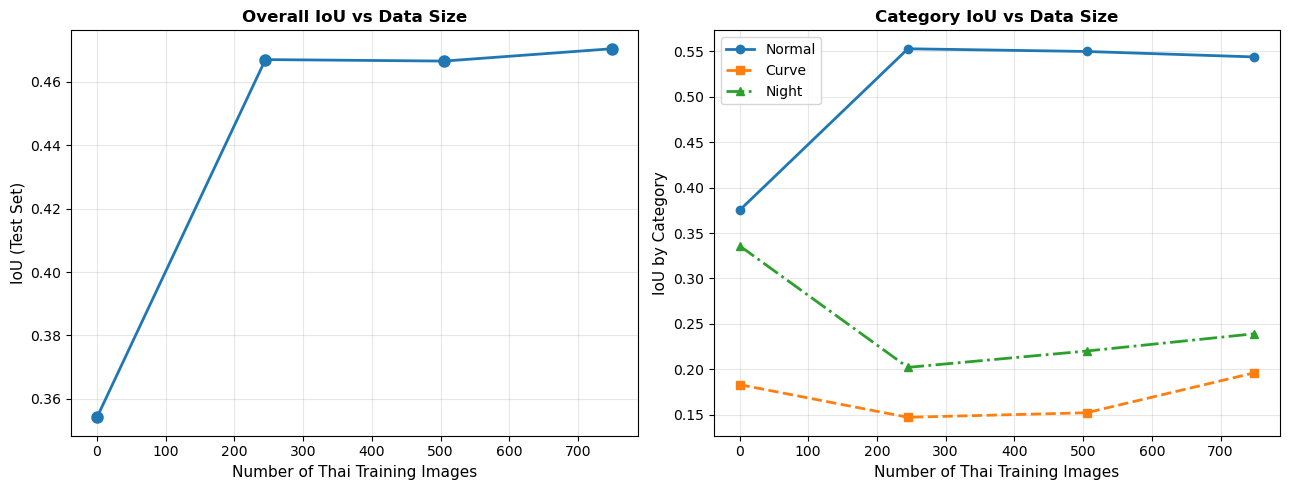

In [7]:
cat_data = {
    'สภาพถนน': ['Normal (ถนนตรงกลางวัน)', 'Curve (ทางโค้ง)', 'Night (กลางคืน)'],
    'Zero-shot (0 รูป)': [0.375, 0.183, 0.336],
    '250 รูป': [0.553, 0.147, 0.202],
    '500 รูป': [0.550, 0.152, 0.220],
    'ทั้งหมด (749 รูป)': [0.544, 0.196, 0.239]
}
cat_df = pd.DataFrame(cat_data)
display(cat_df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# กราฟ 1: IoU ภาพรวม
x = [0, 245, 505, 749]
iou_all = [zero_all['iou'],
           f1_crit[f1_crit['n_thai_train'] == 245]['thai_iou'].values[0],
           f1_crit[f1_crit['n_thai_train'] == 505]['thai_iou'].values[0],
           f1_crit[f1_crit['n_thai_train'] == 749]['thai_iou'].values[0]]

ax1.plot(x, iou_all, 'o-', color='#1f77b4', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Thai Training Images', fontsize=11)
ax1.set_ylabel('IoU (Test Set)', fontsize=11)
ax1.set_title('Overall IoU vs Data Size', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# กราฟ 2: แยกรายหมวด
ax2.plot(x, [0.375, 0.553, 0.550, 0.544], 'o-', label='Normal', linewidth=2)
ax2.plot(x, [0.183, 0.147, 0.152, 0.196], 's--', label='Curve', linewidth=2)
ax2.plot(x, [0.336, 0.202, 0.220, 0.239], '^-.', label='Night', linewidth=2)
ax2.set_xlabel('Number of Thai Training Images', fontsize=11)
ax2.set_ylabel('IoU by Category', fontsize=11)
ax2.set_title('Category IoU vs Data Size', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()
